In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('weight-height.csv')
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


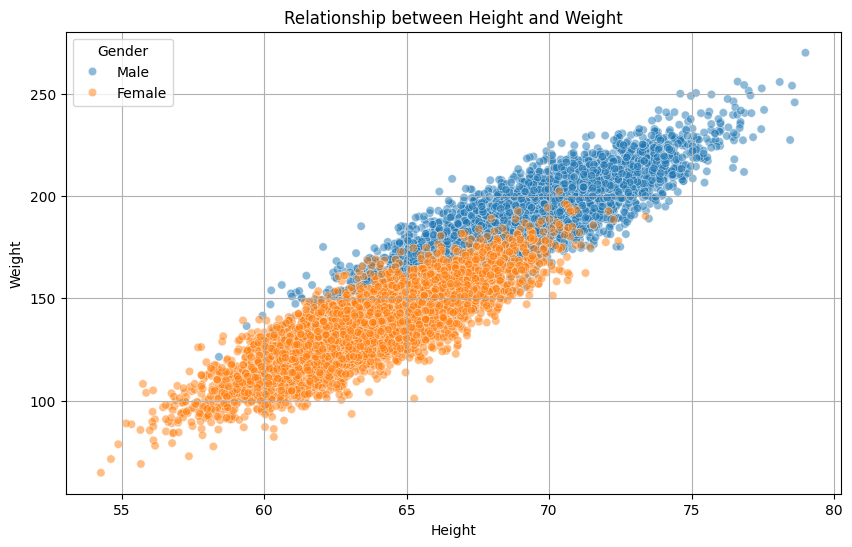

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Gender', alpha=0.5)
plt.title('Relationship between Height and Weight')
plt.grid(True)
plt.show()

In [26]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Selecting features for clustering
X = df[['Height', 'Weight']]

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying DBSCAN
# eps: maximum distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: number of samples in a neighborhood for a point to be considered as a core point
dbscan = DBSCAN(eps=0.2, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

# Adding cluster labels to the dataframe
df['Cluster'] = clusters

# Displaying the count of points in each cluster (-1 indicates noise)
print("Cluster distribution:")
print(df['Cluster'].value_counts())

Cluster distribution:
Cluster
 0    9961
-1      39
Name: count, dtype: int64


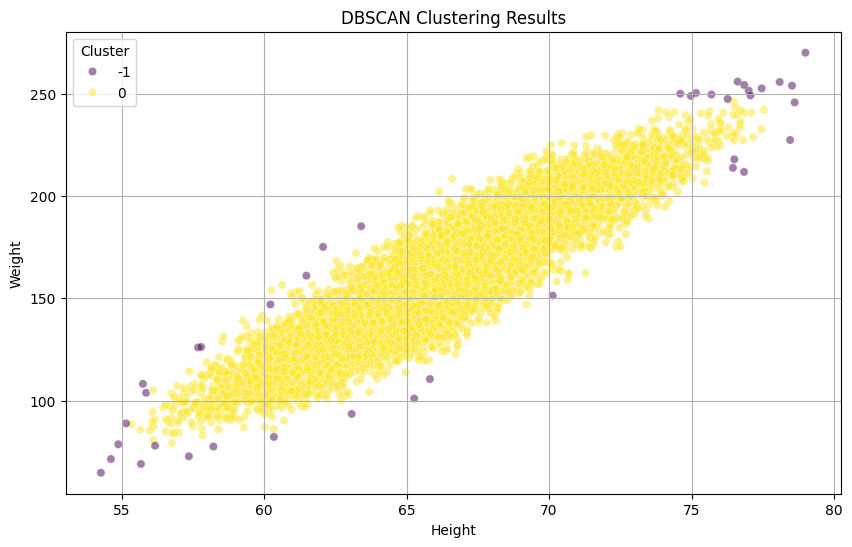

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Cluster', palette='viridis', alpha=0.5)
plt.title('DBSCAN Clustering Results')
plt.grid(True)
plt.show()